# ¡Llena ese carrito!

# Introducción

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.
El conjunto de datos que te hemos proporcionado tiene modificaciones del original. Redujimos el tamaño del conjunto para que tus cálculos se hicieran más rápido e introdujimos valores ausentes y duplicados. Tuvimos cuidado de conservar las distribuciones de los datos originales cuando hicimos los cambios.

Debes completar tres pasos. Para cada uno de ellos, escribe una breve introducción que refleje con claridad cómo pretendes resolver cada paso, y escribe párrafos explicatorios que justifiquen tus decisiones al tiempo que avanzas en tu solución.  También escribe una conclusión que resuma tus hallazgos y elecciones.


## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

# Paso 1. Descripción de los datos

Lee los archivos de datos (`/datasets/instacart_orders.csv`, `/datasets/products.csv`, `/datasets/aisles.csv`, `/datasets/departments.csv` y `/datasets/order_products.csv`) con `pd.read_csv()` usando los parámetros adecuados para leer los datos correctamente. Verifica la información para cada DataFrame creado.


## Plan de solución

Escribe aquí tu plan de solución para el Paso 1. Descripción de los datos.

Se importará la librería pandas y se cargaran los archivos que contienen los datos. Posteriormente se realizará la visualización del contenido de cada DataFrame por medio de los métodos info, head y describe, esto con el fin de poder apreciar con claridad la generalidad de los datos,una versión estadística que me anticipe que encontraré y una pequeña muestra del contenido.

Aunque se puede hacer en una sola caja de código se realizará el ejercicio en 7 espacios diferentes, ya que el precódigo viene con esos espacios predefinidos para hacerlo. Uno para cargar importar librerías, otro para leer conjuntos de datos y 5 para leer individualmente cada DataFrame.

Conforme se realicen hallazgos se irá completando esta sección con hallazgos, correcciones y métodos usados para corregir posibles defectos a encontrar tras la lectura de cada DataFrame.

Se encontró en una primera revisión que todos los Dataframes usan como separador ';' por lo que para poder leer bien los datos y encontrar posibles errores en el interior del conjunto de datos procederemos a usar como segundo parámetro sep= en la función que nos permite cargar los conjuntos de datos, esto porque con sep= le indicamos que ese será el separador predeteminado en lugar de ','. No hay más novedades para este punto.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
instacart_orders= pd.read_csv('/content/instacart_orders.csv', sep=';')
products= pd.read_csv('/content/products.csv', sep=';')
aisles=pd.read_csv('/content/aisles.csv', sep=';')
departments= pd.read_csv('/content/departments.csv', sep=';')
order_products=pd.read_csv('/content/order_products.csv', sep=';')

In [3]:
instacart_orders.info(show_counts=True)
print()
print(instacart_orders.describe())
print()
instacart_orders.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB

           order_id        user_id   order_number      order_dow  \
count  4.789670e+05  478967.000000  478967.000000  478967.000000   
mean   1.709947e+06  102966.537475      17.157808       2.775058   
std    9.869480e+05   59525.328991      17.704688       2.045869   
min    4.000000e+00       2.000000       1.000000       0.000000   
25%    8.564685e+05   51414.000000       5.000000       1.000000  

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0
3,1768857,82516,56,0,20,10.0
4,3007858,196724,2,4,12,17.0


In [4]:
products.info(show_counts=True)
print()
print(products.describe())
print()
products.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB

         product_id      aisle_id  department_id
count  49694.000000  49694.000000   49694.000000
mean   24847.500000     67.773192      11.728478
std    14345.566475     38.317265       5.850314
min        1.000000      1.000000       1.000000
25%    12424.250000     35.000000       7.000000
50%    24847.500000     69.000000      13.000000
75%    37270.750000    100.000000      17.000000
max    49694.000000    134.000000      21.000000



,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [5]:
aisles.info()
print()
print(aisles.describe())
print()
aisles.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB

         aisle_id
count  134.000000
mean    67.500000
std     38.826537
min      1.000000
25%     34.250000
50%     67.500000
75%    100.750000
max    134.000000



,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [6]:
departments.info()
print()
print(departments.describe())
print()
departments.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 468.0+ bytes

       department_id
count      21.000000
mean       11.000000
std         6.204837
min         1.000000
25%         6.000000
50%        11.000000
75%        16.000000
max        21.000000



,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [7]:
order_products.info(show_counts=True)
print()
print(order_products.describe())
print()
order_products.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB

           order_id    product_id  add_to_cart_order     reordered
count  4.545007e+06  4.545007e+06       4.544171e+06  4.545007e+06
mean   1.711166e+06  2.558084e+04       8.351669e+00  5.905025e-01
std    9.850955e+05  1.409552e+04       7.080368e+00  4.917411e-01
min    4.000000e+00  1.000000e+00       1.000000e+00  0.000000e+00
25%    8.608170e+05  1.353500e+04       3.000000e+00  0.000000e+00
50%    1.711530e+06  2.527200e+04       6.000000e+00  1.000000e+00
75%    2.561311e+06  3.793500e+04       1.100000e+01  1.000000e+00

,order_id,product_id,add_to_cart_order,reordered
0,2141543,11440,17.0,0
1,567889,1560,1.0,1
2,2261212,26683,1.0,1
3,491251,8670,35.0,1
4,2571142,1940,5.0,1


## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 1. Descripción de los datos.

En el primer DataFrame: 'instacart_orders', se encuentran 478.967 filas y 6 columnas. Estas últimas, en orden son:  order_id, user_id, order_number, order_dow, order_hour_of_day, days_since_prior_order. Ninguna columna almacena strings, las primeras 5 tienen int todos sus valores completos o por lo menos no nulos. La última (days_since_prior_order) números flotantes, además de registrar 20.000 valores que pueden ser nulos o ausentes, esa ausencia por ahora no parece relevante. Como anticipó el diccionario de los datos, la columna order_dow almacena números de 0 a 6 que representan los días de la semana. La columna order_hour_of_day está en formato int, sin embargo puede ser útil ponerla en formato de hora.

El el segundo Dataframe:'products', se encuentran 49694 filas y 4 columnas, las cuáles respectivamente son: product_id, product_name, aisle_id y department_id. La única columna que no está en formato int es product_name, es también esta columna la única con valores ausentes (más de mil), sin embargo parece una ausencia insignificante con relación al conjunto de datos. Se pueden formatear las columnas deparment_id y aisle_id como datos categóricos si lo llega requerir el análisis.

En el Tercer DataFrame: 'aisles', se encuentran 134 filas con dos columnas, siendo estas respectivamente: aisle_id y aisle. No existen objetos nulos y respectivamente representan el número del pasillo y su nombre, por lo que están formateadas en int y object.

En el cuarto DataFrame: 'department', se encuentran 21 filas y dos columnas, que respectivamente son department_id y department. Al igual que el dataframe 'aisles' representa con un número el id de categoría general al que pertenece el producto y se especifica con su nombre, en consecuencia está formateado como int y object. Tampoco tiene algún valor ausente.

En el quinto DataFrame: 'order_products' es nuestro DataFrame más grande, contiene 4'545.007 filas  y 4 columnas, que son: order_id, product_id,add_to_cart_order y reordered. Su única columna que no está formateada en int es add_to_car_order, pues se encuentra en float además de ser la única columna con valores ausentes o nulos, cerca de mil, lo que no es representativo para cualquier análisis que se vaya a hacer. Quizá no sea necesario que esta columna se encuentre formateada como un flotante.

Todos los DataFrames tienen índices númericos definidos por defecto en 0.






# Paso 2. Preprocesamiento de los datos

Preprocesa los datos de la siguiente manera:

- Verifica y corrige los tipos de datos (por ejemplo, asegúrate de que las columnas de ID sean números enteros).
- Identifica y completa los valores ausentes.
- Identifica y elimina los valores duplicados.

Asegúrate de explicar qué tipos de valores ausentes y duplicados encontraste, cómo los completaste o eliminaste y por qué usaste esos métodos. ¿Por qué crees que estos valores ausentes y duplicados pueden haber estado presentes en el conjunto de datos?

## Plan de solución

Escribe aquí tu plan para el Paso 2. Preprocesamiento de los datos.

En el paso número 1 se encontró en la revisión superficial que se hizo de los 5 conjuntos de datos se encontró que la mayoría corresponden a datos int, que algunas columnas tienes datos ausentes o nulos que no son significativos. Algunos de estos son nombres o strings.

Por lo tanto se revisarán los valores ausentes y se borrarán esas filas con dropna ya que los números no son significativos y no es posible saber cuáles son los nombres de los posibles ausentes. Es posible usar fillna() para rellenar esos valores con el string Unknown, sin embargo es posible que estos productos sin nombre se deban a un error  al momento de la carga. Una vez más la decisión dependerá de lo que nos arroje la revisión de esas filas con valores ausentes.

No es posible establecer la revisión de números duplicados en esa primera revisión, por lo que se usará duplicated para revisar la existencia de filas duplicadas y dropduplicates para 'limpiar' el DataFrame de esas filas que pueden conducir a conclusiones erroneas. Como la tabla tiene en su mayoría valores númericos que al provenir de una plataforma de compras se asume que los valores ingresaron automáticamente en el sistema, solo se revisarán los duplicados implícitos de columnas como producto, ya que un error humano en el momento de su creación puede crear dos nombres para un mismo producto.

También, se realizarán las conversiones de columnas a que haya lugar según requieran las instrucciones para prganizar el DataFrame según las instrucciones y requisitos del proyecto. Todo esto se desarrollará de manera simultanea según las instrucciones del precódigo y se utilizarán varias cajas de código ya que así lo establece el mismo.

## Encuentra y elimina los valores duplicados (y describe cómo tomaste tus decisiones).

### `orders` data frame

In [8]:
# Revisa si hay pedidos duplicados
instacart_orders.duplicated().sum()

np.int64(15)

¿Tienes líneas duplicadas? Si sí, ¿qué tienen en común?

In [9]:
# Basándote en tus hallazgos,
# Verifica todos los pedidos que se hicieron el miércoles a las 2:00 a.m.
instacart_orders_duplicated= instacart_orders[(instacart_orders['order_dow'] == 3) & (instacart_orders['order_hour_of_day'] == 2)]
instacart_orders_duplicated['duplicates'] = instacart_orders_duplicated.duplicated()
print(instacart_orders_duplicated.tail(60))

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
250626    467134    63189            21          3                  2   
255538    577527     5253            96          3                  2   
256910    593561   134463            12          3                  2   
257934   1919531   191501            32          3                  2   
259636   2282673    86751            49          3                  2   
260453   1211189     7300             5          3                  2   
262169   1099720    57529             1          3                  2   
262212   2625221     8394            19          3                  2   
265247   1219044   122453             5          3                  2   
266232   1782114   106752             1          3                  2   
273805   1112182   202304            84          3                  2   
275163    401662    15693             2          3                  2   
284038   2845099    31189            11          3 

<ipython-input-9-14f126d939e4>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  instacart_orders_duplicated['duplicates'] = instacart_orders_duplicated.duplicated()


¿Qué sugiere este resultado?
El resultado sugiere que las filas duplicadas se generaron el miércoles a las 2 a.m., anque el motivo es desconocido se puede deber a una falla técnica del sistema que duplicó en ciertas ocasiones la orden, bien sea por una falla en el sistema o por un problema de los dispositivos que generaron la orden.

In [10]:
# Elimina los pedidos duplicados
instacart_orders.drop_duplicates(inplace=True)
instacart_orders.drop_duplicates().reset_index(drop=True)

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0
3,1768857,82516,56,0,20,10.0
4,3007858,196724,2,4,12,17.0
...,...,...,...,...,...,...
478947,3210681,5617,5,1,14,7.0
478948,3270802,112087,2,3,13,6.0
478949,885349,82944,16,2,11,6.0
478950,216274,4391,3,3,8,8.0


In [11]:
# Vuelve a verificar si hay filas duplicadas
instacart_orders.duplicated().sum()

np.int64(0)

In [12]:
# Vuelve a verificar únicamente si hay IDs duplicados de pedidos
ids_duplicates= instacart_orders['order_id'].duplicated().sum()
print(ids_duplicates)

0


Describe brevemente tus hallazgos y lo que hiciste con ellos

En el primer DataFrame se encontraron 15 filas duplicadas, que se encontraban en el día miércoles a las 2:00 a.m. Para ello se usó el método drop.duplicates y se reestableció el valor de los índices. Además por solicitud del precódigo se revisó que no existieran duplicados en la columna 'order_id', se realizó el mismo procedimiento sin encontrar valores duplicados.  

### `products` data frame

In [13]:
# Verifica si hay filas totalmente duplicadas
products.duplicated().sum()

np.int64(0)

In [14]:
# Revisa únicamente si hay ID de productos duplicados
product_id_dup = products['product_id'].duplicated().sum()
print(product_id_dup)

0


In [15]:
# Revisa únicamente si hay nombres duplicados de productos (convierte los nombres a letras mayúsculas para compararlos mejor)
#Número de valores no nulos en el Data Frame: 48436
products['product_name']=products['product_name'].str.upper()
product_name_dup= products['product_name'].duplicated().sum()
condicion= products['product_name'].duplicated()
print('Número de nombres duplicados:',product_name_dup)
print(products[condicion].sample(50))

Número de nombres duplicados: 1361
       product_id                       product_name  aisle_id  department_id
20370       20371                                NaN       100             21
43573       43574                                NaN       100             21
8844         8845                                NaN       100             21
38238       38239                                NaN       100             21
11388       11389                                NaN       100             21
47334       47335                                NaN       100             21
16272       16273                                NaN       100             21
47184       47185  SPREADABLE BUTTER WITH CANOLA OIL        36             16
20363       20364                     MATZO BALL MIX        33              6
29853       29854             MUENSTER CHEESE SLICES         2             16
17482       17483                                NaN       100             21
49481       49482            

In [16]:
# Revisa si hay nombres duplicados de productos no faltantes
product_wot_nans = products.dropna(subset='product_name')
product_wot_nans = product_wot_nans['product_name'].duplicated().sum()
print('Nombres duplicados de productos no faltantes:',product_wot_nans)

Nombres duplicados de productos no faltantes: 104


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Al revisar los valores duplicados se encontró que aunque no hay filas completamente duplicadas, sí hay nombres de producto duplicados, más de la mitad de estos corresponde a valores ausentes. Solo 104 valores son duplicados explícitos en la columna 'product_name'. No se borra ninguno de estos duplicados porque aún no es posible saber si pueden, o no ,interferir con otro dataset en el futuro, o con los análisis derivados que se deban hacer.

### `departments` data frame

In [17]:
# Revisa si hay filas totalmente duplicadas
departments.duplicated().sum()

np.int64(0)

In [18]:
# Revisa únicamente si hay IDs duplicadas de departamentos
departments['department_id'].duplicated().sum()

np.int64(0)

Describe brevemente tus hallazgos y lo que hiciste con ellos.

No se encuentran duplicados, por lo tanto no se realiza ninguna acción en el DataFrame.

### `aisles` data frame

In [19]:
# Revisa si hay filas totalmente duplicadas
aisles.duplicated().sum()

np.int64(0)

In [20]:
# Revisa únicamente si hay IDs duplicadas de pasillos
aisles['aisle_id'].duplicated().sum()

np.int64(0)

Describe brevemente tus hallazgos y lo que hiciste con ellos.

No se encuentran duplicados, por lo tanto no se realiza ninguna acción en el DataFrame.

### `order_products` data frame

In [21]:
# Revisa si hay filas totalmente duplicadas
order_products.duplicated().sum()

np.int64(0)

In [22]:
# Vuelve a verificar si hay cualquier otro duplicado engañoso
order_id_dup = order_products['order_id'].duplicated().sum()
product_id_dup_2 = order_products['product_id'].duplicated().sum()

print(order_id_dup)
print(product_id_dup_2)

4094961
4499434


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Se encuentran duplicados en los ID de orden y producto, sin embargo no se eliminan porque estos obedecen a la dinámica en que se comportó cada orden de compra, lo que puede ser importante para nuestros análisis.

## Encuentra y elimina los valores ausentes

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products` data frame

In [23]:
# Encuentra los valores ausentes en la columna 'product_name'
filter= products['product_name'].isna()
print(products['product_name'].isna().sum())
print(products[filter].head(50))

1258
      product_id product_name  aisle_id  department_id
37            38          NaN       100             21
71            72          NaN       100             21
109          110          NaN       100             21
296          297          NaN       100             21
416          417          NaN       100             21
436          437          NaN       100             21
439          440          NaN       100             21
471          472          NaN       100             21
490          491          NaN       100             21
555          556          NaN       100             21
561          562          NaN       100             21
613          614          NaN       100             21
623          624          NaN       100             21
689          690          NaN       100             21
767          768          NaN       100             21
803          804          NaN       100             21
890          891          NaN       100             21
990  

Describe brevemente cuáles son tus hallazgos.

Hay 1258 datos ausentes, en la columna 'product_name', posiblemente todos asociados al pasillo 100 y departamento 21.  

In [24]:
#  ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?
filter_100 = products[(products['product_name'].isna()) & (products['aisle_id'] == 100)]
filter_by_100 = products['aisle_id'] == 100
print(filter_100)
print(filter_by_100.sum())

       product_id product_name  aisle_id  department_id
37             38          NaN       100             21
71             72          NaN       100             21
109           110          NaN       100             21
296           297          NaN       100             21
416           417          NaN       100             21
...           ...          ...       ...            ...
49552       49553          NaN       100             21
49574       49575          NaN       100             21
49640       49641          NaN       100             21
49663       49664          NaN       100             21
49668       49669          NaN       100             21

[1258 rows x 4 columns]
1258


Describe brevemente cuáles son tus hallazgos.

En efecto, pareciera que los datos ausentes  de este DataFrame se encuentran asiociados al pasillo 100, sino que todos corresponden al departamento 21. Y que tan id 100, como product_name NaN no están relacionados con ningún otro producto o pasillo.

In [25]:
# ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?
filter_100 = products[(products['product_name'].isna()) & (products['aisle_id'] == 100)]
filter_by_100 = products['aisle_id'] == 100
print(filter_100)
print(filter_by_100.sum())

       product_id product_name  aisle_id  department_id
37             38          NaN       100             21
71             72          NaN       100             21
109           110          NaN       100             21
296           297          NaN       100             21
416           417          NaN       100             21
...           ...          ...       ...            ...
49552       49553          NaN       100             21
49574       49575          NaN       100             21
49640       49641          NaN       100             21
49663       49664          NaN       100             21
49668       49669          NaN       100             21

[1258 rows x 4 columns]
1258


Describe brevemente cuáles son tus hallazgos.

In [26]:
# Usa las tablas department y aisle para revisar los datos del pasillo con ID 100 y el departamento con ID 21.
filter_21 = filter_100['department_id'] == 21
filter_by_21 = products['department_id'] == 21
print(filter_21.sum())
print(filter_by_21.sum())

1258
1258


Describe brevemente cuáles son tus hallazgos.

Sin importar si se filtra el DataFrame o no, es más que claro en este momento que los datos ausentes corresponden al pasillo 100 y al departamento 21.

In [27]:
# Completa los nombres de productos ausentes con 'Unknown'
products['product_name']=products['product_name'].fillna('Unknown')
print(products.isna().sum())

product_id       0
product_name     0
aisle_id         0
department_id    0
dtype: int64


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Según las instrucciones del proyecto, se reemplazan los valores ausentes por el string 'Unknwon'. Se comprueba inmediatamente que ya no hay valores ausentes en el DataFrame.

### `orders` data frame

In [28]:
# Encuentra los valores ausentes
show_orders_isna= instacart_orders.isna().sum()
print(show_orders_isna)

order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28817
dtype: int64


In [29]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?
show_prior_order= instacart_orders['days_since_prior_order'].isna()
filtro_de_prueba= instacart_orders['user_id'] == 182261
print(instacart_orders[show_prior_order].head(50))
print(instacart_orders[filtro_de_prueba].head(20))

instacart_orders['days_since_prior_order']=instacart_orders['days_since_prior_order'].fillna(0)
show_orders_isna= instacart_orders.isna().sum()
print('Comprobación de valores ausentes', show_orders_isna)

      order_id  user_id  order_number  order_dow  order_hour_of_day  \
28      133707   182261             1          3                 10   
96      787445    25685             1          6                 18   
100     294410   111449             1          0                 19   
103    2869915   123958             1          4                 16   
104    2521921    42286             1          3                 18   
111    2651928   142920             1          0                 14   
118     174214   148907             1          1                  8   
147    2439694    99710             1          6                 10   
157    1330993   138895             1          4                  6   
158    2835610   195350             1          6                 19   
284    2463923    37043             1          1                 19   
292    1644166    48924             1          1                 10   
302    1263637   146988             1          0                  8   
316   

Describe brevemente tus hallazgos y lo que hiciste con ellos.

Se encontraron datos ausentes en la columna days_since_prior_order, se comprobó que todos estos datos obedecían a la primera vez que el cliente realizó un pedido con la aplicación, se reemplazó ese valor con 0.

### `order_products` data frame

In [30]:
# Encuentra los valores ausentes
order_products.isna().sum()

,0
order_id,0
product_id,0
add_to_cart_order,836
reordered,0


In [31]:
# ¿Cuáles son los valores mínimos y máximos en esta columna?
min_column_3 = order_products['add_to_cart_order'].min()
max_column_3 =order_products['add_to_cart_order'].max()
print('valor mínimo:', min_column_3,'valor máximo:',max_column_3)

valor mínimo: 1.0 valor máximo: 64.0


Describe brevemente cuáles son tus hallazgos.

Solo se encontraron valores ausentes en la columna número 3 'add_to_cart_order', con un total de 836. Esto se puede deber a que los productos fueron retirados y el sistema igualmente los contó sin atribuirles un valor.

In [32]:
# Guarda todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'

id_order_in_order_products = order_products.query('add_to_cart_order.isna()') ['order_id']
print(id_order_in_order_products)

737        2449164
9926       1968313
14394      2926893
16418      1717990
30114      1959075
            ...   
4505662    1800005
4511400    1633337
4517562     404157
4534112    1673227
4535739    1832957
Name: order_id, Length: 836, dtype: int64


In [33]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
# Agrupa todos los pedidos con datos ausentes por su ID de pedido.
# Cuenta el número de 'product_id' en cada pedido y revisa el valor mínimo del conteo.
grupro_idorder_productid= order_products.groupby(id_order_in_order_products)['product_id'].count()
print(grupro_idorder_productid)
print('Valor mínimo del conteo:', grupro_idorder_productid.min())

filter_order_id= order_products.query('order_id in @id_order_in_order_products')
filter_order_id.query('add_to_cart_order > 63')

tercer_filtro= order_products.query('order_id == 1386261') [['order_id', 'product_id','add_to_cart_order']]
tercer_filtro['add_to_cart_order'] = tercer_filtro['add_to_cart_order'].sort_values(ascending=False)

print(tercer_filtro.head(60))

order_id
9310.0        1
61355.0      63
102236.0     31
129627.0      5
165801.0      6
             ..
2999801.0     6
3125735.0    22
3308010.0    51
3347453.0     7
3383594.0     5
Name: product_id, Length: 70, dtype: int64
Valor mínimo del conteo: 1
         order_id  product_id  add_to_cart_order
13226     1386261       47866               29.0
76044     1386261       31847               64.0
92005     1386261       21607               54.0
94722     1386261       41007                NaN
235181    1386261       33364               47.0
245086    1386261       17949                7.0
285571    1386261       42846                NaN
307642    1386261       25533               63.0
391919    1386261       27086                4.0
489540    1386261       24852               46.0
572254    1386261        8324                NaN
651500    1386261       34635                NaN
678125    1386261       12807                NaN
724098    1386261       26047               16.0
769752    

Describe brevemente cuáles son tus hallazgos.

Al parecer la hipótesis planteada en el precódigo es cierta. Se probó con tres tipos de filtro distintos, el que se pide en el precódigo, un .query que permita establecer si es cierto que el DataFrame no tiene más valores después de 65 y un filtro que probara esa condición con un id de compra al azar de los que arrojaban NaN. El resultado: Todas las compras con más de 64 elementos en el carrito de compras arroja NaN para los números siguientes.

In [34]:
# Remplaza los valores ausentes en la columna 'add_to_cart? con 999 y convierte la columna al tipo entero.
order_products['add_to_cart_order']=order_products['add_to_cart_order'].fillna(999)
print(order_products.isna().sum())

np.array_equal(order_products['add_to_cart_order'],order_products['add_to_cart_order'].astype('int'))
order_products['add_to_cart_order']= order_products['add_to_cart_order'].astype('int')
order_products.info()
print(order_products['add_to_cart_order'].head(10))

order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype
---  ------             -----
 0   order_id           int64
 1   product_id         int64
 2   add_to_cart_order  int64
 3   reordered          int64
dtypes: int64(4)
memory usage: 138.7 MB
0    17
1     1
2     1
3    35
4     5
5     4
6     5
7    10
8    14
9     4
Name: add_to_cart_order, dtype: int64


Describe brevemente tus hallazgos y lo que hiciste con ellos.
Más que hallazgos, se reemplazaron  los valores ausentes por el valor indicado en el precódigo y se convirtió la columna a tipo entero.

## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 2. Preprocesamiento de los datos


En contraste con lo señalado en la introducción, no se borró ningún duplicado debido a que podía alterar los datos. Simplemente se revisó a que se debían esos duplicados y siguiendo las instrucciones del proyecto se trataron, en los casos en que así fuera requerido. En el caso de los valores ausentes, en lugar de eliminar las filas se reemplazaron por otro tipo de valores que respondieran a su categoría. No se eliminó ninguna filao dato, tanto para duplicados como para valores ausentes.

# Paso 3. Análisis de los datos

Una vez los datos estén procesados y listos, haz el siguiente análisis:

# [A] Fácil (deben completarse todos para aprobar)

1. Verifica que los valores en las columnas `'order_hour_of_day'` y `'order_dow'` en la tabla orders sean razonables (es decir, `'order_hour_of_day'` oscile entre 0 y 23 y `'order_dow'` oscile entre 0 y 6).
2. Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.
3. Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
4. Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.

### [A1] Verifica que los valores sean sensibles

In [35]:
#Verificación order_hour_of_day
verificacion_valores_ohod= instacart_orders['order_hour_of_day'].unique()
verificacion_valores_ohod.sort()
print(verificacion_valores_ohod)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


In [36]:
#Verificación order_dow
verificacion_valores_od= instacart_orders['order_dow'].unique()
verificacion_valores_od.sort()
print(verificacion_valores_od)

[0 1 2 3 4 5 6]


Escribe aquí tus conclusiones

Los valores de las columnas 'order_hour_of_day' y 'order_dow', corresponden a los esperados, es decir: 0-23 y 0-6 respectivamente.

### [A2] Para cada hora del día, ¿cuántas personas hacen órdenes?

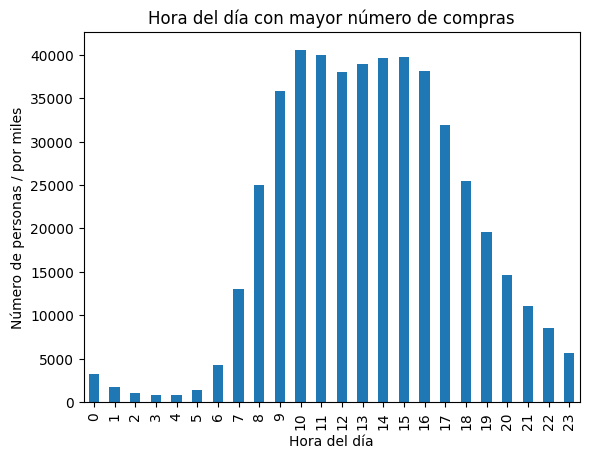

In [37]:
#Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día

instacart_orders['order_hour_of_day']=instacart_orders['order_hour_of_day'].astype('category')
df_instacart_odhd= instacart_orders['order_hour_of_day'].value_counts()
df_instacart_odhd = df_instacart_odhd.sort_index()
df_instacart_odhd.plot(x='order_hour_of_day', kind='bar', title= 'Hora del día con mayor número de compras', xlabel= 'Hora del día', ylabel='Número de personas / por miles')
plt.show()


Escribe aquí tus conclusiones

Es indudable que la hora con mayor tráfico es a las 10 de la mañana, aunque el tráfico se mantiene considerablemente alto hasta las 4:00 p.m. (en horario de 12 horas o '16' como aparece en la gráfica.).

### [A3] ¿Qué día de la semana compran víveres las personas?

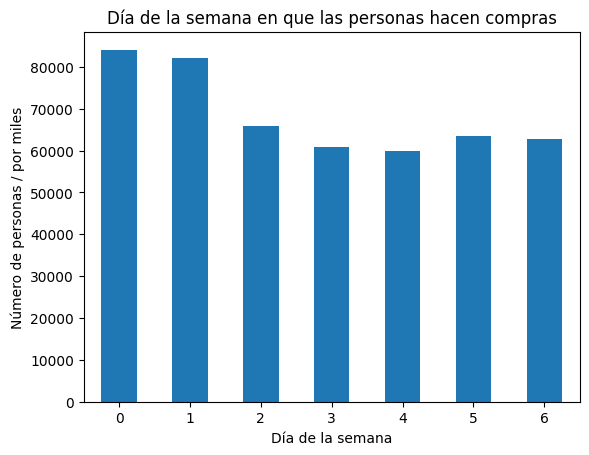

In [38]:
#Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
instacart_orders['order_dow']=instacart_orders['order_dow'].astype('category')
df_instacart_od= instacart_orders['order_dow'].value_counts()
df_instacart_od = df_instacart_od.sort_index()
df_instacart_od.plot(x='order_dow', kind='bar', title= 'Día de la semana en que las personas hacen compras', xlabel= 'Día de la semana', ylabel='Número de personas / por miles', rot= 0)
plt.show()

Escribe aquí tus conclusiones

Se comprueba que domingo y lunes son los días con mayor número de ventas, aunque el tráfico se mantiene el resto de la semana.

### [A4] ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

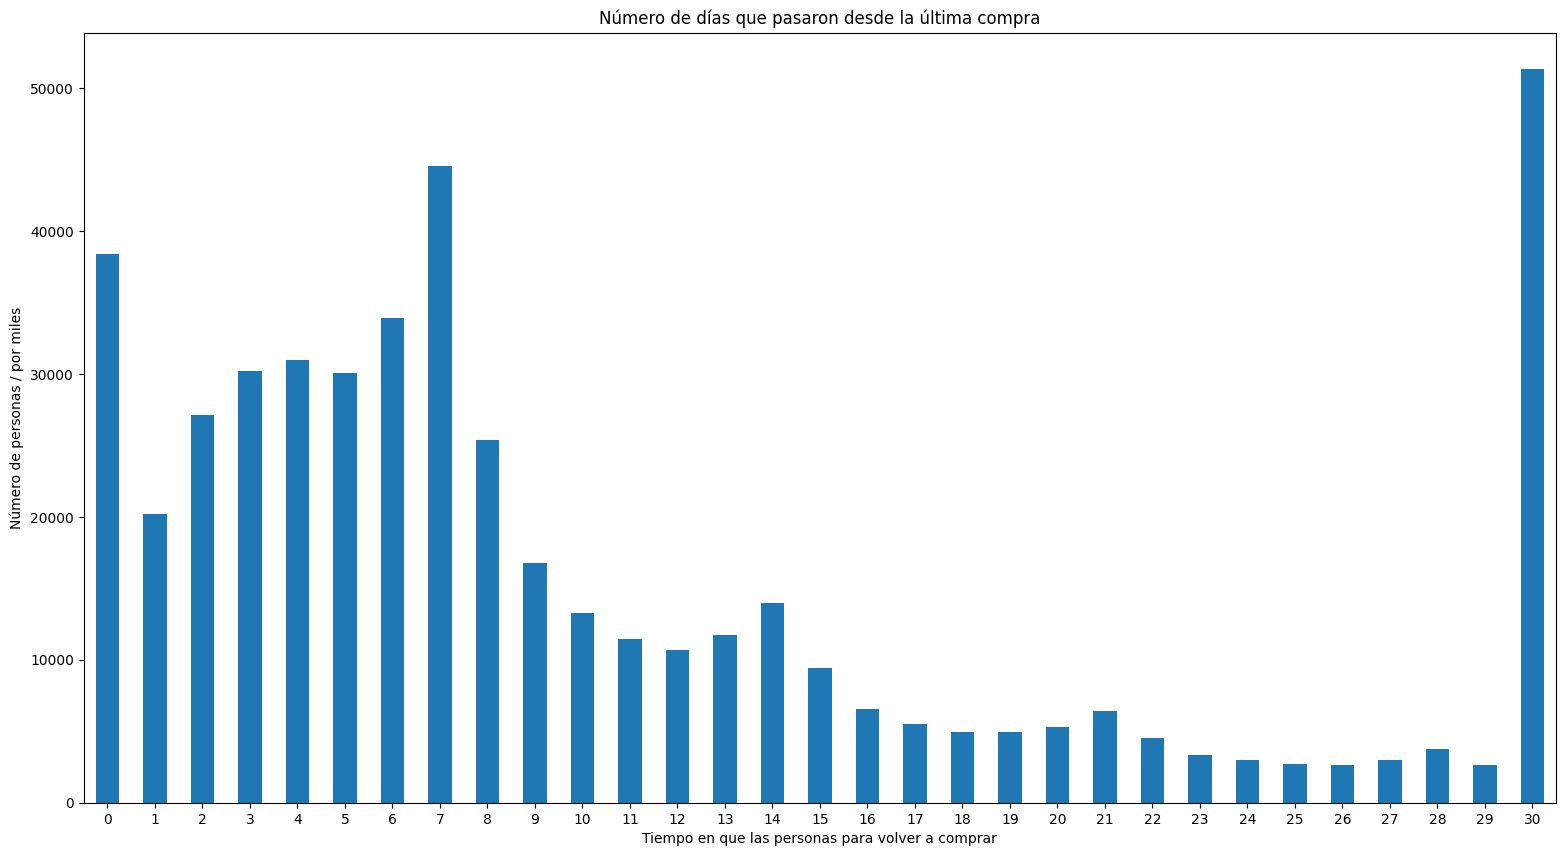

In [39]:
#Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.
instacart_orders['days_since_prior_order']=instacart_orders['days_since_prior_order'].astype('int')
instacart_orders['days_since_prior_order']=instacart_orders['days_since_prior_order'].astype('category')
df_instacart_dspo= instacart_orders['days_since_prior_order'].value_counts()
df_instacart_dspo = df_instacart_dspo.sort_index()

df_instacart_dspo.plot(x= 'index', y= '', kind='bar', title= 'Número de días que pasaron desde la última compra', xlabel= 'Tiempo en que las personas para volver a comprar', ylabel='Número de personas / por miles', rot=0, figsize=(19,10))
plt.show()


Escribe aquí tus conclusiones

Casi una quinta parte espera casi un mes para volver a comprar. Un alto número de personas realiza compras en menos de una semana. No hay personas que no hayan vuelto a realizar compras en más de un mes. Se puede decir que hay un grupo que se concentra en hacer un pedido en menos de una semana  y otro que lo aplaza durante el mes e incluso puede dejar pasar un tiempo considerable, superior a dos semanas, antes de volver a realizar un pedido.

Se destacan también las personas que, al parecer, todos los día piden, cuyo valor en el eje x de la tabla es: '0' y las personas que piden exactamente a los 8 días, cuya posición en el eje x es: '7'.

El tiempo que las personas más tardan en realizar un nuevo pedido es 30 días. Irónicamente, el menor número de personas está representado por 29 días, es decir, personas que hicieron un pedido hoy y esperaron 29 días en realizar otro.

Como última anotación es importante señalar que hay unos picos en los primeros días del mes y que se reduce hasta el final de mes, lo que quiere decir que este comportamiento puede estar relacionado con el dia de paga.

# [B] Intermedio (deben completarse todos para aprobar)

1. ¿Existe alguna diferencia entre las distribuciones `'order_hour_of_day'` de los miércoles y los sábados? Traza gráficos de barra de `'order_hour_of_day'` para ambos días en la misma figura y describe las diferencias que observes.
2. Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).
3. ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?

### [B1] Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

In [40]:
# ¿Existe alguna diferencia entre las distribuciones 'order_hour_of_day' de los miércoles y los sábados? Traza gráficos de barra de 'order_hour_of_day' para ambos días en la misma figura y describe las diferencias que observes.
#separación de valores de la columna order_dow
miercoles = instacart_orders.query('order_dow == 3')[['order_hour_of_day']].value_counts().sort_index()
sabado = instacart_orders.query('order_dow == 6')[['order_hour_of_day']].value_counts().sort_index()


<ipython-input-40-ef50ae08753c>:3: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  miercoles = instacart_orders.query('order_dow == 3')[['order_hour_of_day']].value_counts().sort_index()
<ipython-input-40-ef50ae08753c>:4: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  sabado = instacart_orders.query('order_dow == 6')[['order_hour_of_day']].value_counts().sort_index()


In [41]:
sabado


,count
order_hour_of_day,
0,464
1,254
2,177
3,125
4,118
5,161
6,451
7,1619
8,3246


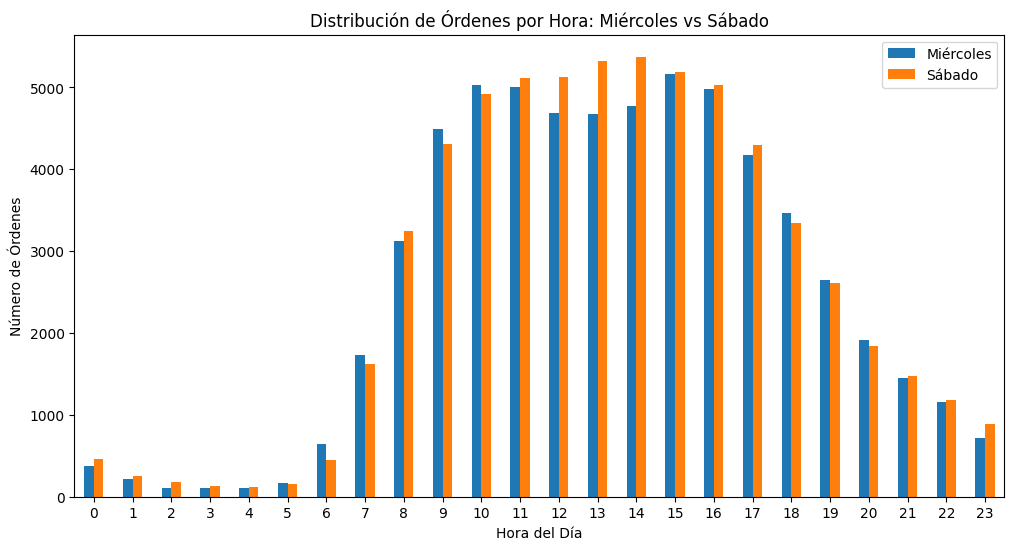

In [42]:
miercoles_y_sabado_counts = pd.concat([miercoles, sabado], axis=1).reset_index()
miercoles_y_sabado_counts.columns = ['order_hour_of_day','Miércoles', 'Sábado']
miercoles_y_sabado_counts.plot(kind='bar', figsize=(12, 6), title='Distribución de Órdenes por Hora: Miércoles vs Sábado', xlabel='Hora del Día', ylabel='Número de Órdenes',x='order_hour_of_day', y= ['Miércoles','Sábado'],rot=0)
plt.show()





Escribe aquí tus conclusiones

Aunque en apariencia, sábados y miércoles tienen un comportamiento similar, se puede ver que las tendencias no son las mismas para estos días.

El miércoles es un día con crecimiento en las primeras horas de la mañana, logrando estabilidad en la mitad del día y alcanzando su pico a las 3:00 p.m. justo antes de empezar a descender.

El sábado, en cambio, hay crecimiento continuo desde las 6 de la mañanana, logrando un crecimiento exponencial de 7:00 a.m. a 2:00 p.m., siendo esta última hora en la que logra la mayor concentración de pedidos  e inmediatamente empieza a descender, sustancialmente hasta las 10:00 p.m.

Es interesante porque hay una sutil diferencia entre ambos días. mientras el miércoles recibe en las primeras horas de la mañana más pedidos que el sábado al medio día se invierte la tendencia y el sábado comienza a dominar la gráfica alcanzando una igualdad relativa desde las 3:00 p.m. que se mantiene hasta las 10:00 p.m.

El sábado puede ser un día más rentable, en la medida en que la concentración del medio día tiene sutilmente más compras.

### [B2] ¿Cuál es la distribución para el número de pedidos por cliente?

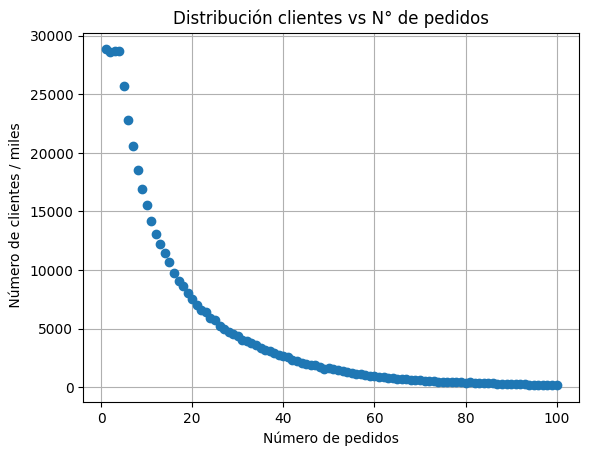

In [43]:
#Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).
numero_de_ordenes = instacart_orders['order_number'].value_counts()

numero_de_ordenes.plot(style='o', title= 'Distribución clientes vs N° de pedidos',xlabel= 'Número de pedidos', ylabel= ' Número de clientes / miles', grid= True)
plt.show()

Escribe aquí tus conclusiones

Como era de esperarse, son más los clientes que realizan entre 1 y 10 pedidos que los que realizan más 20 pedidos.
Los que hacen más de 60 pedidos son muy pocos.
Después de 20 pedidos son menos de 5.000 clientes.

### [B3] ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?

In [44]:
#¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?
producto_mas_pedido= order_products['product_id'].value_counts()
producto_mas_pedido = producto_mas_pedido

print(producto_mas_pedido)
nombre_producto = products.query('product_id in @producto_mas_pedido.index')[['product_id','product_name']]
print(nombre_producto)

product_id
24852    66050
13176    53297
21137    37039
21903    33971
47209    29773
         ...  
23703        1
18003        1
22264        1
16672        1
27048        1
Name: count, Length: 45573, dtype: int64
       product_id                                       product_name
0               1                         CHOCOLATE SANDWICH COOKIES
1               2                                   ALL-SEASONS SALT
2               3               ROBUST GOLDEN UNSWEETENED OOLONG TEA
3               4  SMART ONES CLASSIC FAVORITES MINI RIGATONI WIT...
6               7                     PURE COCONUT WATER WITH ORANGE
...           ...                                                ...
49689       49690                      HIGH PERFORMANCE ENERGY DRINK
49690       49691                      ORIGINAL PANCAKE & WAFFLE MIX
49691       49692    ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR
49692       49693                             SPRING WATER BODY WASH
49693       49694       

In [45]:
nombre_y_id_df= nombre_producto.merge(producto_mas_pedido, how='right', left_on='product_id', right_on='product_id')
print(nombre_y_id_df.head(20))

    product_id              product_name  count
0        24852                    BANANA  66050
1        13176    BAG OF ORGANIC BANANAS  53297
2        21137      ORGANIC STRAWBERRIES  37039
3        21903      ORGANIC BABY SPINACH  33971
4        47209      ORGANIC HASS AVOCADO  29773
5        47766           ORGANIC AVOCADO  24689
6        47626               LARGE LEMON  21495
7        16797              STRAWBERRIES  20018
8        26209                     LIMES  19690
9        27845        ORGANIC WHOLE MILK  19600
10       27966       ORGANIC RASPBERRIES  19197
11       22935      ORGANIC YELLOW ONION  15898
12       24964            ORGANIC GARLIC  15292
13       45007          ORGANIC ZUCCHINI  14584
14       39275       ORGANIC BLUEBERRIES  13879
15       49683            CUCUMBER KIRBY  13675
16       28204        ORGANIC FUJI APPLE  12544
17        5876             ORGANIC LEMON  12232
18        8277  APPLE HONEYCRISP ORGANIC  11993
19       40706    ORGANIC GRAPE TOMATOES

Escribe aquí tus conclusiones

**Los 20 productos más comprados son:**
         
|    | product_id | Nombre del producto |
|----|------------|----------|
| 1  | 24852      | BANANA  |
| 2  | 13176      | BAG OF ORGANIC BANANAS|
| 3  | 21137      | ORGANIC STRAWBERRIES|
| 4  | 21903      | ORGANIC BABY SPINACH  |
| 5  | 47209      | ORGANIC HASS AVOCADO  |
| 6  | 47766      | ORGANIC AVOCADO|
| 7  | 47626      | LARGE LEMON |
| 8  | 16797      | STRAWBERRIES  |
| 9  | 26209      | LIMES|
| 10 | 27845      | ORGANIC WHOLE MILK  |
| 11 | 27966      | ORGANIC RASPBERRIES|
| 12 | 22935      | ORGANIC YELLOW ONION|
| 13 | 24964      |ORGANIC GARLIC  |
| 14 | 45007                      |ORGANIC ZUCCHINI   |
| 15 | 39275        | ORGANIC BLUEBERRIES  |
| 16 | 49683   | CUCUMBER KIRBY |
| 17 | 28204  | ORGANIC FUJI APPLE |
| 18 | 5876  | ORGANIC LEMON |
| 19 | 8277   | APPLE HONEYCRISP ORGANIC|
| 20 | 40706  | ORGANIC GRAPE TOMATOES  |

Se puede decir que el top 10 de pedidos está compuesto por vegetales y frutas cuya característica común es el adjetivo 'orgánico', lo que indica un interés de nuestros clientes en comida saludable y que sus métodos de cultivo sean amigables con el medio ambiente.

# [C] Difícil (deben completarse todos para aprobar)

1. ¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?
2. ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?
3. Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?
4. Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.
5. ¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?

### [C1] ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

In [46]:
#¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?
numero_de_pedidos= order_products.groupby('order_id').count()['product_id']

print(numero_de_pedidos)


order_id
4          13
9          15
11          5
19          3
20          8
           ..
3421034    17
3421053     9
3421071     5
3421077     4
3421079     1
Name: product_id, Length: 450046, dtype: int64


In [47]:
productos_por_pedido= numero_de_pedidos.value_counts().sort_index()
print(productos_por_pedido)

product_id
1      21847
2      26292
3      29046
4      31054
5      31923
       ...  
98         1
104        1
108        1
115        1
127        1
Name: count, Length: 90, dtype: int64


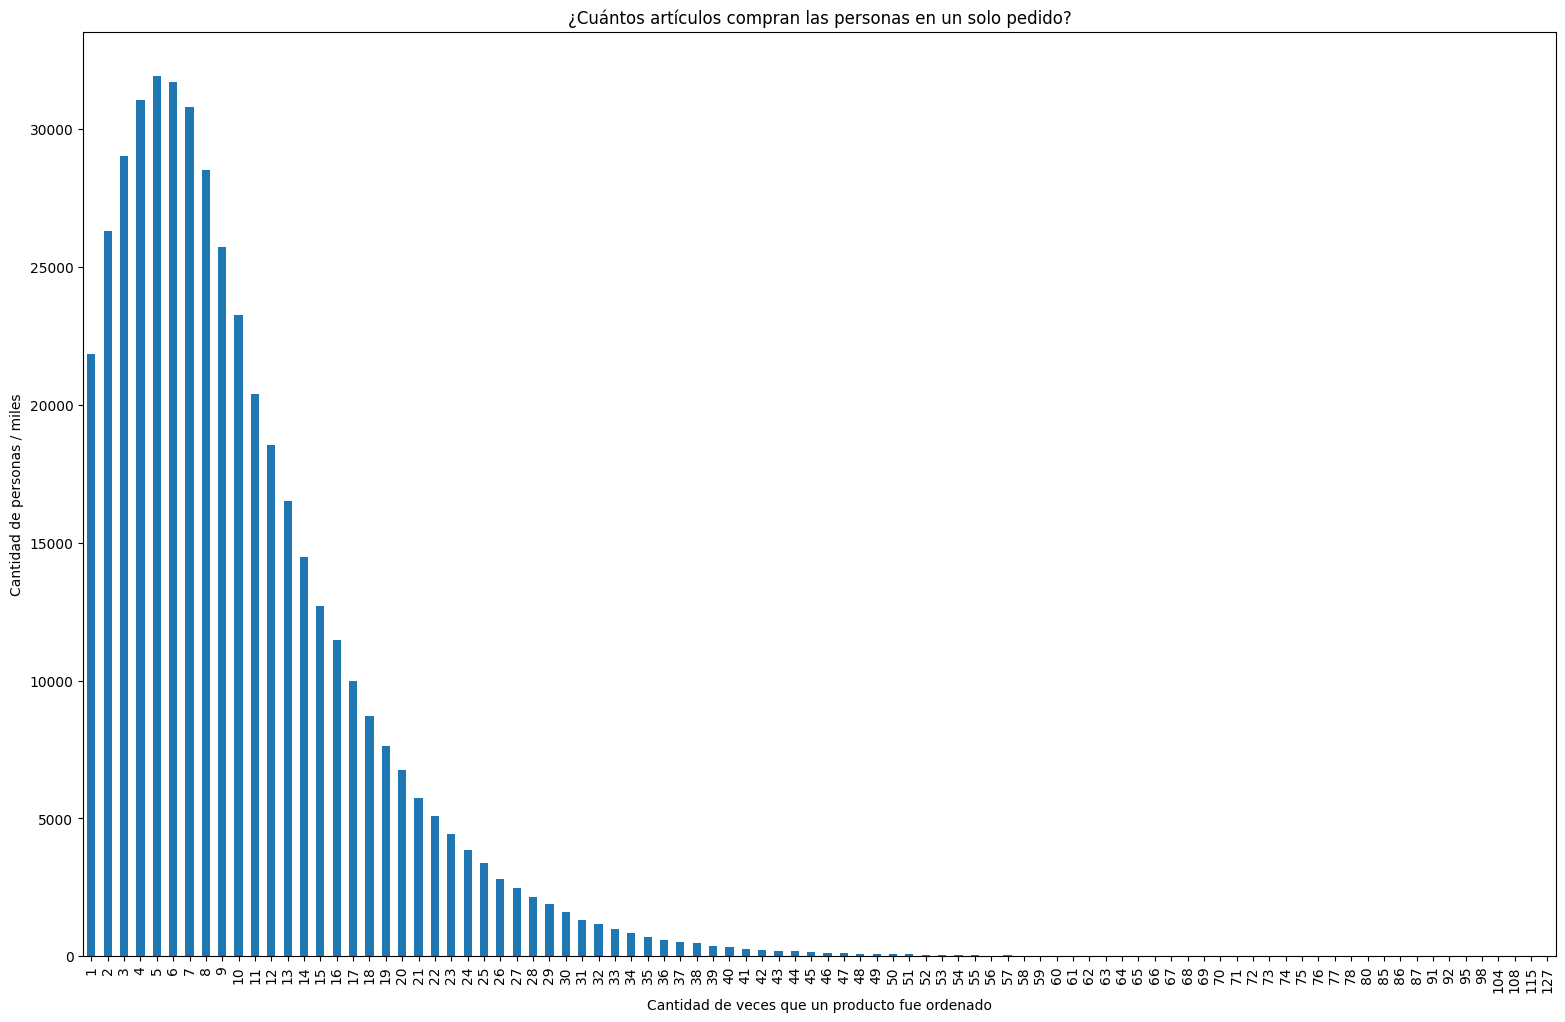

In [48]:
productos_por_pedido.plot(kind='bar',figsize=(19,12),title= '¿Cuántos artículos compran las personas en un solo pedido?', xlabel= 'Cantidad de veces que un producto fue ordenado', ylabel= 'Cantidad de personas / miles')
plt.show()

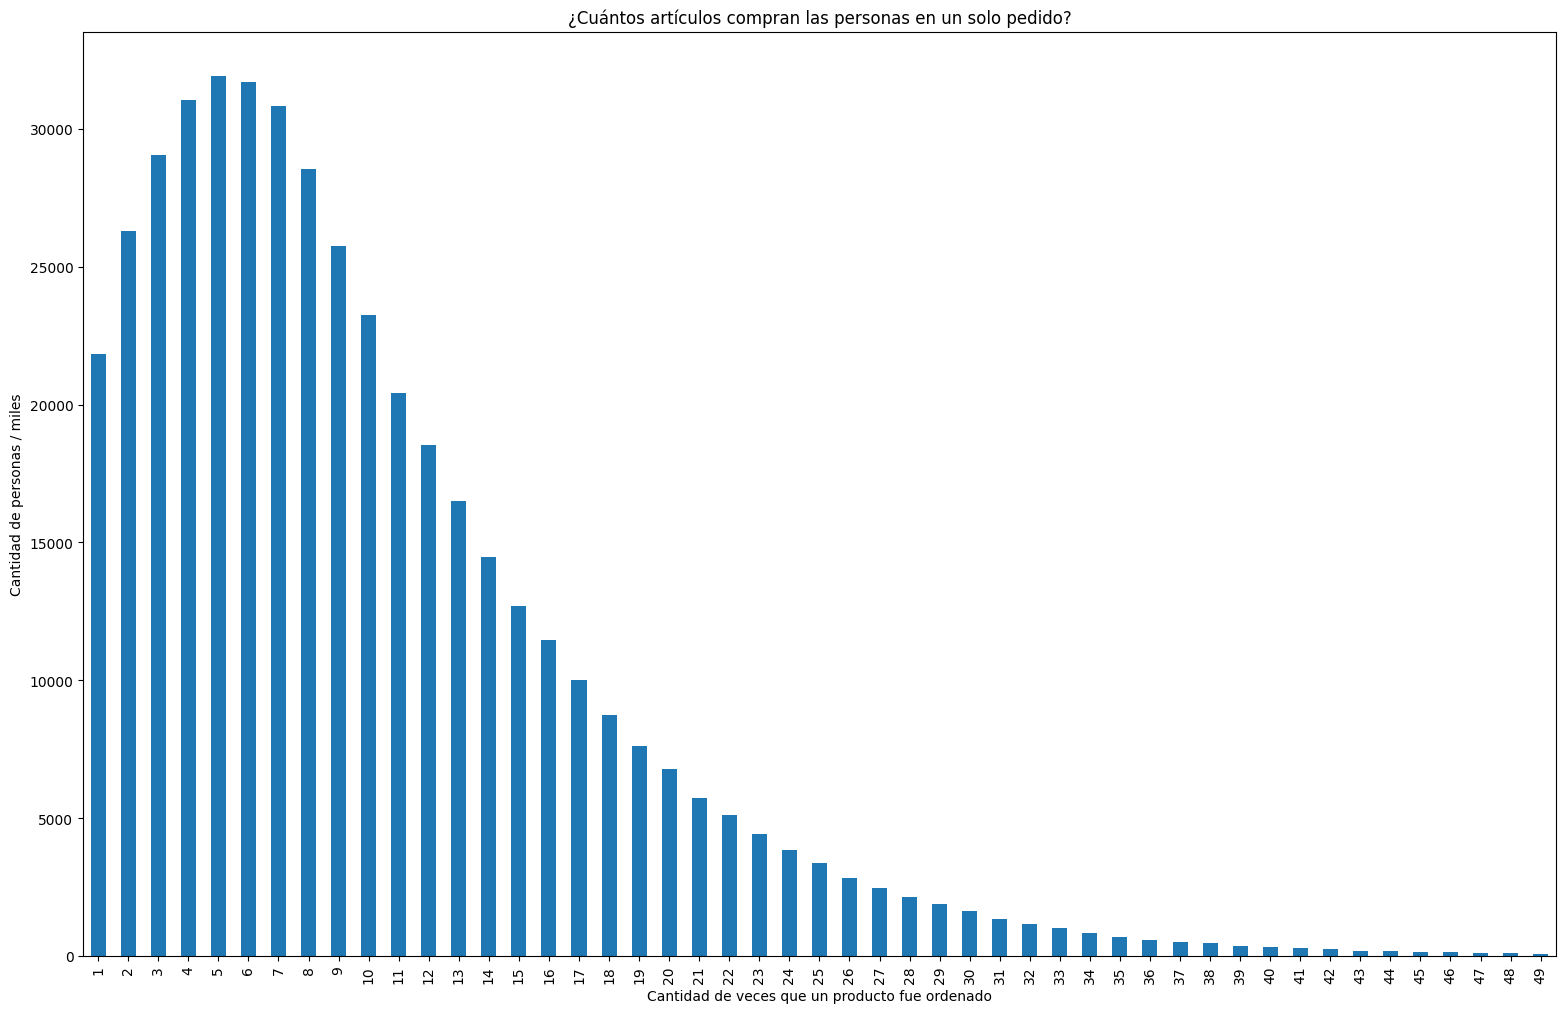

In [49]:
productos_por_pedido[productos_por_pedido.index < 50].plot(kind='bar',figsize=(19,12),title= '¿Cuántos artículos compran las personas en un solo pedido?', xlabel= 'Cantidad de veces que un producto fue ordenado', ylabel= 'Cantidad de personas / miles' )
plt.show()

Escribe aquí tus conclusiones

En promedio, las personas ordenan entre 4 y 7 artículos por compra.

### [C2] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

In [50]:
#¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?
productos_reordenados = order_products.query('reordered == 1')
conteo_productos_reordenados = productos_reordenados.groupby('product_id')['add_to_cart_order'].count().sort_values(ascending=False)
print(conteo_productos_reordenados)




product_id
24852    55763
13176    44450
21137    28639
21903    26233
47209    23629
         ...  
41219        1
41253        1
41252        1
41284        1
41281        1
Name: add_to_cart_order, Length: 36228, dtype: int64


In [51]:
nombre_producto_reordenado = products.query('product_id in @conteo_productos_reordenados.index')[['product_id','product_name']]
print(nombre_producto.head(20))

    product_id                                       product_name
0            1                         CHOCOLATE SANDWICH COOKIES
1            2                                   ALL-SEASONS SALT
2            3               ROBUST GOLDEN UNSWEETENED OOLONG TEA
3            4  SMART ONES CLASSIC FAVORITES MINI RIGATONI WIT...
6            7                     PURE COCONUT WATER WITH ORANGE
7            8                  CUT RUSSET POTATOES STEAM N' MASH
8            9                  LIGHT STRAWBERRY BLUEBERRY YOGURT
9           10     SPARKLING ORANGE JUICE & PRICKLY PEAR BEVERAGE
10          11                                  PEACH MANGO JUICE
11          12                         CHOCOLATE FUDGE LAYER CAKE
12          13                                  SALINE NASAL MIST
13          14                     FRESH SCENT DISHWASHER CLEANER
16          17                                  RENDERED DUCK FAT
17          18                PIZZA FOR ONE SUPREMA  FROZEN PIZZA
18        

In [52]:
nombre_y_id_reordenado_df= nombre_producto_reordenado.merge(conteo_productos_reordenados, how='right', left_on='product_id', right_on='product_id')
print(nombre_y_id_reordenado_df.head(20))

    product_id              product_name  add_to_cart_order
0        24852                    BANANA              55763
1        13176    BAG OF ORGANIC BANANAS              44450
2        21137      ORGANIC STRAWBERRIES              28639
3        21903      ORGANIC BABY SPINACH              26233
4        47209      ORGANIC HASS AVOCADO              23629
5        47766           ORGANIC AVOCADO              18743
6        27845        ORGANIC WHOLE MILK              16251
7        47626               LARGE LEMON              15044
8        27966       ORGANIC RASPBERRIES              14748
9        16797              STRAWBERRIES              13945
10       26209                     LIMES              13327
11       22935      ORGANIC YELLOW ONION              11145
12       24964            ORGANIC GARLIC              10411
13       45007          ORGANIC ZUCCHINI              10076
14       49683            CUCUMBER KIRBY               9538
15       28204        ORGANIC FUJI APPLE

Escribe aquí tus conclusiones

**Los 20 productos comprados  más reordenados son:**
         
|    | product_id | Nombre del producto |
|----|------------|----------|
| 1  | 24852      | BANANA  |
| 2  | 13176      | BAG OF ORGANIC BANANAS|
| 3  | 21137      | ORGANIC STRAWBERRIES|
| 4  | 21903      | ORGANIC BABY SPINACH  |
| 5  | 47209      | ORGANIC HASS AVOCADO  |
| 6  | 47766      | ORGANIC AVOCADO|
| 7  | 47626      | ORGANIC WHOLE MILK  |
| 8  | 16797      | LARGE LEMON  |
| 9  | 26209      | ORGANIC RASPBERRIES|
| 10 | 27845      | STRAWBERRIES |
| 11 | 27966      | LIMES|
| 12 | 22935      | ORGANIC YELLOW ONION|
| 13 | 24964      |ORGANIC GARLIC  |
| 14 | 45007       |ORGANIC ZUCCHINI   |
| 15 | 39275        |  CUCUMBER KIRBY  |
| 16 | 49683   | ORGANIC FUJI APPLE|
| 17 | 28204  |APPLE HONEYCRISP ORGANIC  |
| 18 | 5876  | ORGANIC BLUEBERRIES |
| 19 | 8277   |ORGANIC LEMON |
| 20 | 40706  | ORGANIC HALF & HALF  |

Se corroborá que  que el top 10 de pedidos está compuesto por vegetales y frutas cuya característica común es el adjetivo 'orgánico', lo que indica un interés de nuestros clientes en comida saludable y que sus métodos de cultivo sean amigables con el medio ambiente.

Ahora, es curioso que en los 20 productos más reordenados en las compras hay variaciones sutiles. Los bananos, el aguacate, las moras y la espinaca bebé siguen liderando, pero aparecen productos como el 'ORGANIC HALF & HALF' que no aparecieron en la tabla de los 20 productos más vendidos.

### [C3] Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

In [53]:
#Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?
total_orders_x_producto =order_products['product_id'].value_counts()
print(total_orders_x_producto )

repeticiones_producto = order_products.query('reordered ==1')[['product_id']]
conteo_repeticiones_producto = repeticiones_producto['product_id'].value_counts()
print(conteo_repeticiones_producto)


product_id
24852    66050
13176    53297
21137    37039
21903    33971
47209    29773
         ...  
23703        1
18003        1
22264        1
16672        1
27048        1
Name: count, Length: 45573, dtype: int64
product_id
24852    55763
13176    44450
21137    28639
21903    26233
47209    23629
         ...  
35313        1
18946        1
19440        1
27533        1
13247        1
Name: count, Length: 36228, dtype: int64


In [54]:
order_products_concat= pd.concat([total_orders_x_producto,conteo_repeticiones_producto], axis='columns')
order_products_concat.columns=['total_pedido','repeticiones']
order_products_concat['repeticiones'] = order_products_concat['repeticiones'].fillna(0)
order_products_concat['repeticiones']=order_products_concat['repeticiones'].astype('int')
print(order_products_concat)



            total_pedido  repeticiones
product_id                            
24852              66050         55763
13176              53297         44450
21137              37039         28639
21903              33971         26233
47209              29773         23629
...                  ...           ...
23703                  1             0
18003                  1             0
22264                  1             1
16672                  1             1
27048                  1             0

[45573 rows x 2 columns]


            total_pedido  repeticiones  tasa_repeticion
product_id                                             
24852              66050         55763         0.844254
13176              53297         44450         0.834006
21137              37039         28639         0.773212
21903              33971         26233         0.772217
47209              29773         23629         0.793639
...                  ...           ...              ...
23703                  1             0         0.000000
18003                  1             0         0.000000
22264                  1             1         1.000000
16672                  1             1         1.000000
27048                  1             0         0.000000

[45573 rows x 3 columns]
promedio general: 0.38670677893645006


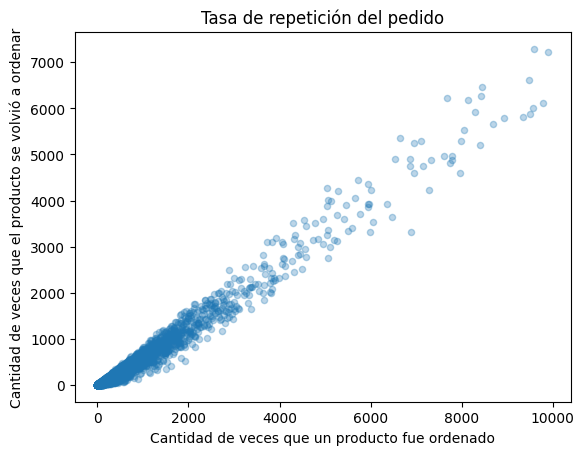

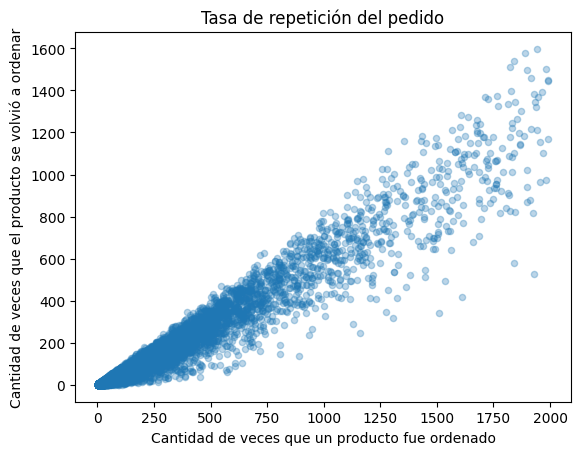

In [56]:
order_products_concat['tasa_repeticion'] = order_products_concat['repeticiones']/order_products_concat['total_pedido']
promedio_general_order_products_concat= order_products_concat['tasa_repeticion'].mean()
print(order_products_concat)
print('promedio general:',promedio_general_order_products_concat)

order_products_concat[order_products_concat.total_pedido < 10000].plot(kind='scatter', x='total_pedido', y='repeticiones', title= 'Tasa de repetición del pedido', xlabel= 'Cantidad de veces que un producto fue ordenado', ylabel= 'Cantidad de veces que el producto se volvió a ordenar',alpha=0.3)
order_products_concat[order_products_concat.total_pedido < 2000].plot(kind='scatter', x='total_pedido', y='repeticiones', title= 'Tasa de repetición del pedido', xlabel= 'Cantidad de veces que un producto fue ordenado', ylabel= 'Cantidad de veces que el producto se volvió a ordenar',alpha=0.3)
plt.show()

Escribe aquí tus conclusiones

El éxito comercial de un producto nos de qué tan aceptado es y cuánto lo desea la gente. Por ejemplo, hay productos que se ordenaron una vez y no se volvieron a ordenar nunca, ni siquiera por su primer comprador. En contraste con los ya conocidos 20 más vendidos. A pesar lo que nos indica la tasa de recompra es que hay una fuerte tendencia a no volver ordernar esos artículos. Muy pocos productos sobrepasan la relación entre ser pedidos y 'repedidos'.

### [C4] Para cada cliente, ¿qué proporción de sus productos ya los había pedido?

In [91]:
#Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.

combinados= order_products.merge(instacart_orders, on= 'order_id',how='inner')
result= combinados.groupby('user_id')['reordered'].mean().reset_index()
result['reordered']=result['reordered']*100
print(result)

        user_id  reordered
0             2   3.846154
1             4   0.000000
2             5  66.666667
3             6   0.000000
4             7  92.857143
...         ...        ...
149621   206203  22.222222
149622   206206  71.428571
149623   206207  89.130435
149624   206208  69.600000
149625   206209  32.000000

[149626 rows x 2 columns]


<Axes: ylabel='Frequency'>

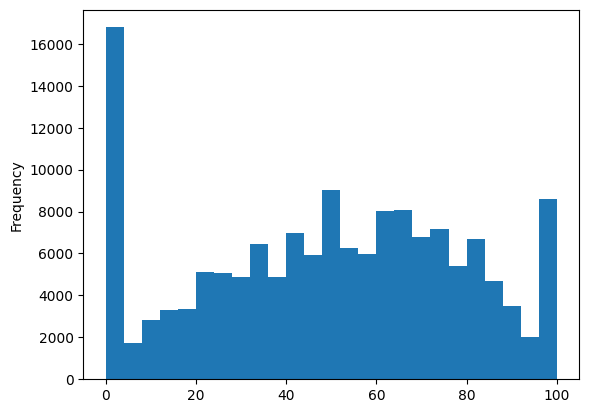

In [96]:
result['reordered'].plot(kind='hist',bins=25)

Escribe aquí tus conclusiones

1 de cada 2 productos se vuelve a pedir.

### [C5] ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

In [87]:
#¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?
order_by_orden_de_compra = order_products.query('add_to_cart_order == 1')[['product_id']]
primeros_productos= order_by_orden_de_compra.value_counts().reset_index()
print(primeros_productos)

       product_id  count
0           24852  15562
1           13176  11026
2           27845   4363
3           21137   3946
4           47209   3390
...           ...    ...
26755          43      1
26756          41      1
26757          33      1
26758       21942      1
26759       21935      1

[26760 rows x 2 columns]


In [103]:
#merge
df_merge= primeros_productos.merge(products, on='product_id')
df_merge= df_merge.drop('aisle_id',axis=1)
df_merge= df_merge.drop('department_id',axis=1)
#nombres_de_columnas={'product_id':'product_id','count':'N° de veces que fue el primer artículo', 'product_name':'product_name'}
df_merge = df_merge.rename(columns={'product_id':'product_id','count':'N° de veces que fue el primer artículo', 'product_name':'product_name'})
df_merge.head(20)

,product_id,N° de veces que fue el primer artículo,product_name
0,24852,15562,BANANA
1,13176,11026,BAG OF ORGANIC BANANAS
2,27845,4363,ORGANIC WHOLE MILK
3,21137,3946,ORGANIC STRAWBERRIES
4,47209,3390,ORGANIC HASS AVOCADO
5,21903,3336,ORGANIC BABY SPINACH
6,47766,3044,ORGANIC AVOCADO
7,19660,2336,SPRING WATER
8,16797,2308,STRAWBERRIES
9,27966,2024,ORGANIC RASPBERRIES


Escribe aquí tus conclusiones

Los primeros resultados de la tabla siguen liderando. Eso quiere decir que están en el top of mind de las personas: Bananos y aguacate orgánico. Siguen predominando los productos orgánicos.

### Conclusion general del proyecto:

Tras realizar varios análisis se puede concluir que los productos orgánicos representan una participación muy importante en los pedidos realizados por los clientes. Que los productos más pedidos son frutas y verduras. Quizá esto tenga relación con las horas de mayor tráfico, que suelen ser cerca del medio día justo sobre el almuerzo.

En la presentación de los datos hay que revisar posibles errores de recepción de la data, por ejemplo, en products 'product_names' hay valores desconocidos lo que puede indicar fallas en el inventario o productos con una descarga incompleta del sistema o instacart cuya columna 'days_sin_prior_order' tiene valores que faltan.

Llama la atención que la opción de volver a pedir con nosotros no es significativa. La mayoría de productos no se vuelven a pedir de una forma tan masiva como los 20 primeros. De igual forma, los clientes que hicieron un pedido con nosotros, no l o vuelven a hacer por más de una semana hasta casi un mes. Es como si fueramos la plataforma de inicio y fin de mes.